In [2]:
gt_ip = pd.read_csv('ehn-gt-cleaned-inpatient-20251223000.csv')
gt_ip.head()

,admitdate,dischargedate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,ehn_practice,lhn,entity,cost,paiddate,placeofservice,placeofservicedescription,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicefacility,servicefacilitynpi,readmission,readmission60,readmission90,followup7dayind,followup30daytcoc,dischargedisposition
0,2024-12-22,2024-12-29,56a053a2c5f5a16146246c8cd206b15f,Emory Anthem Commercial,BUFORD,GA,30519,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,304.8100,2025-01-09,55,Residential Substance Abuse Treatment Facility,86480,TB CELL MEDIATED ANTIGN RESPNSE GAMMA INTERFERON,F13.20,"Sedative, hypnotic or anxiolytic dependence, u...",1033749940,Clinical Medical Laboratory,IP BEHAVIORAL HEALTH,"SUNRISE DETOX ALPHARETTA, LLC",1427440999,1,1,1,1,218.3600,HOME
1,2024-11-30,2024-12-13,282bfaa0946165ec48dd67c64bd43a67,Emory Anthem Commercial,UNION CITY,GA,30291,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,"217,605.9400",2025-01-30,21,Inpatient Hospital,88350,IMMUNOFLUORESCENCE PR SPEC EA ADD SINGL ANTB STN,C83.38,"Diffuse large B-cell lymphoma, lymph nodes of ...",1699084145,Pathology,IP SURGICAL (ADULT),"PAULDING MEDICAL CENTER, INC.",1457329435,0,0,0,0,"862,755.4200",HOME
2,2024-12-04,2024-12-16,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,"9,172.0700",2025-01-17,31,Skilled Nursing Facility,99306,INITIAL NURSING FACILITY CARE HI MDM 50 MINUTES,G93.41,Metabolic encephalopathy,1104355908,Nurse Practitioner,IP SNF,"ENGLAND ASSOCIATES, LP",1144530148,0,0,0,1,"3,814.6000",HOME
3,2024-11-30,2024-12-04,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,"11,803.0400",2024-12-13,21,Inpatient Hospital,99239,HOSPITAL IP/OBS DISCHARGE DAY MGMT > 30 MIN,U07.1,COVID-19,1245736172,Internal Medicine,IP MEDICAL (ADULT),"EASTSIDE MEDICAL CENTER, LLC",1467406132,0,0,0,0,"13,180.3600",IP SNF
4,2024-05-13,2024-05-16,503d9c68c71212bda9697f48ee3a5580,Emory Anthem Commercial,VILLA RICA,GA,30180,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,"25,410.1300",2024-06-06,21,Inpatient Hospital,59400,OB CARE ANTEPARTUM VAG DLVR & POSTPARTUM,O99.824,Streptococcus B carrier state complicating chi...,1023301660,Obstetrics & Gynecology,IP SNF,"TANNER MEDICAL CENTER, INC",1801883780,0,0,0,1,"8,141.2000",HOME


In [3]:
#gt_ip.dtypes

In [4]:
print('Unique patients :', gt_ip['deid_personid'].nunique())
print('Unique visits   :', len(gt_ip))

Unique patients : 16991
Unique visits   : 24206


---
## 2. Feature Engineering

All features are derived from visit-level data and aggregated to patient level.  
**Design principle:** features must represent information that would be available *prior to* knowing the outcome — no components of `total_cost` are used as predictors of the high-cost label.

In [5]:
# LOS
gt_ip['admitdate']     = pd.to_datetime(gt_ip['admitdate'])
gt_ip['dischargedate'] = pd.to_datetime(gt_ip['dischargedate'])
gt_ip['los_days']      = (gt_ip['dischargedate'] - gt_ip['admitdate']).dt.days.clip(lower=0)

In [6]:
# --- 2.1 patient-level summary ---
patient_summary = (
    gt_ip.groupby('deid_personid', as_index=False)
    .agg(
        n_visits        = ('deid_personid', 'size'),
        total_cost      = ('cost', 'sum'),          
        total_los_days  = ('los_days', 'sum'),       
        avg_los_days    = ('los_days', 'mean'),
        n_readmit_30    = ('readmission', 'sum'),
        n_readmit_60    = ('readmission60', 'sum'),
        n_readmit_90    = ('readmission90', 'sum'),
    )
)

# avg_cost_per_visit
patient_summary['avg_cost_per_visit'] = ( patient_summary['total_cost'] / patient_summary['n_visits'])

In [7]:
# --- 2.2  Costliest diagnosis per patient ---
costliest_dx = (
    gt_ip.groupby(['deid_personid', 'icddescription'], as_index=False)
    .agg(total_dx_cost=('cost', 'sum'))
    .sort_values(['deid_personid', 'total_dx_cost'], ascending=[True, False])
    .drop_duplicates(subset='deid_personid')
    .rename(columns={'icddescription': 'costliest_dx'})
    [['deid_personid', 'costliest_dx']]
)

# --- 2.3  Dominant specialty per patient ---
dominant_specialty = (
    gt_ip.groupby(['deid_personid', 'servicing_specialty'])
    .size()
    .reset_index(name='n_events')
    .sort_values(['deid_personid', 'n_events'], ascending=[True, False])
    .drop_duplicates(subset='deid_personid')
    .rename(columns={'servicing_specialty': 'dominant_specialty'})
    [['deid_personid', 'dominant_specialty']]
)

# --- 2.4  Clinical diversity ---
dx_diversity = (
    gt_ip.groupby('deid_personid')['icddescription']
    .nunique()
    .reset_index(name='n_unique_dx')
)

spec_diversity = (
    gt_ip
    .groupby('deid_personid')['servicing_specialty']
    .nunique()
    .reset_index(name='n_unique_specialties')
)

In [8]:
# --- 2.5  Assemble patient-level df ---
patient_model_df = (
    patient_summary
    .merge(costliest_dx,       on='deid_personid', how='left')
    .merge(dominant_specialty, on='deid_personid', how='left')
    .merge(dx_diversity,       on='deid_personid', how='left')
    .merge(spec_diversity,     on='deid_personid', how='left')
)

print(patient_model_df.shape)
patient_model_df.head(3)

(16991, 13)


,deid_personid,n_visits,total_cost,total_los_days,avg_los_days,n_readmit_30,n_readmit_60,n_readmit_90,avg_cost_per_visit,costliest_dx,dominant_specialty,n_unique_dx,n_unique_specialties
0,0001f1a308be5f84297fc5986537253a,1,"23,034.2900",5,5.0000,0,0,0,"23,034.2900","Atrioventricular block, complete",Clinical Cardiac Electrophysiology,1,1
1,0005d1a76d48de5ae0fbe0b7e3d52648,2,"36,842.9500",25,12.5000,0,0,0,"18,421.4750",Nondisplaced intertrochanteric fracture of rig...,General Practice,2,2
2,0006d561ad6a6112d1058426fcac7c80,2,"23,268.3000",11,5.5000,1,1,1,"11,634.1500",Heart transplant rejection,Infectious Disease,2,2


---
## 3. Label Definition

In [9]:
# High-cost labels (p90 and p95 thresholds)
p90 = patient_model_df["total_cost"].quantile(0.90)
p95 = patient_model_df["total_cost"].quantile(0.95)

for pct, col in [(0.90, "high_cost_p90"), (0.95, "high_cost_p95")]:
    threshold = patient_model_df["total_cost"].quantile(pct)
    patient_model_df[col] = (patient_model_df["total_cost"] >= threshold).astype(int)

# Readmission label: any 30-day readmission across the patient's history
patient_model_df['any_readmit_30'] = (patient_model_df['n_readmit_30'] > 0).astype(int)

print(f'p90 cost threshold : ${p90:,.2f}')
print(f'p95 cost threshold : ${p95:,.2f}')
print()
print('Label prevalence:')
print(patient_model_df[['high_cost_p90', 'high_cost_p95', 'any_readmit_30']].mean().rename('rate'))

p90 cost threshold : $77,186.83
p95 cost threshold : $123,696.61

Label prevalence:
high_cost_p90    0.1001
high_cost_p95    0.0500
any_readmit_30   0.0748
Name: rate, dtype: float64


---
## 4. Exploratory Summary

In [10]:
# Numeric feature distributions
patient_model_df[[
    'n_visits', 'avg_los_days', 'n_unique_dx', 'n_unique_specialties',
    'total_cost', 'avg_cost_per_visit'
]].describe().T

,count,mean,std,min,25%,50%,75%,max
n_visits,"16,991.0000",1.4246,1.0335,1.0000,1.0000,1.0000,1.0000,24.0000
avg_los_days,"16,991.0000",5.4069,8.9367,0.0000,2.0000,3.0000,6.0000,371.0000
n_unique_dx,"16,991.0000",1.3409,0.8007,1.0000,1.0000,1.0000,1.0000,10.0000
n_unique_specialties,"16,991.0000",1.2843,0.6748,1.0000,1.0000,1.0000,1.0000,8.0000
total_cost,"16,991.0000","39,888.2980","96,389.4419","-5,935.8000","11,323.1050","19,915.6000","38,363.0850","4,506,790.0500"
avg_cost_per_visit,"16,991.0000","27,718.7015","57,611.3627","-5,935.8000","9,942.1000","16,350.1700","27,271.4800","3,469,864.4400"


In [11]:
# Feature correlations  (model features + label, numeric only)
#corr_cols = ['n_visits', 'avg_los_days', 'n_unique_dx', 'n_unique_specialties', 'high_cost_p90']
#patient_model_df[corr_cols].corr().style.background_gradient(cmap='coolwarm', axis=None)

---
## 5. Feature Sets and Split

In [12]:
numeric_fts = ['n_visits', 'avg_los_days', 'n_unique_dx', 'n_unique_specialties']
categorical_fts = ['costliest_dx', 'dominant_specialty']
all_fts = numeric_fts + categorical_fts

X = patient_model_df[all_fts].copy()

# High-cost (p90)
y_cost = patient_model_df['high_cost_p90'].copy()

# 30-day readmission
y_readmit = patient_model_df['any_readmit_30'].copy()


X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_cost,
    test_size = 0.20, 
    random_state = 42, 
    stratify = y_cost
)

X_train, X_test, yr_train, yr_test = train_test_split(
    X, y_readmit, 
    test_size = 0.20, 
    random_state = 42, 
    stratify = y_readmit
)

print(f'Train size : {len(X_train):,} patients')
print(f'Test size  : {len(X_test):,} patients')
print(f'\nHigh-cost base rate  — train: {yc_train.mean():.3f} | test: {yc_test.mean():.3f}')
print(f'Readmission base rate — train: {yr_train.mean():.3f} | test: {yr_test.mean():.3f}')

Train size : 13,592 patients
Test size  : 3,399 patients

High-cost base rate  — train: 0.100 | test: 0.100
Readmission base rate — train: 0.075 | test: 0.075


---
## 6. Helper Functions

In [13]:
def build_baseline_pipeline(numeric_cols, categorical_cols):
    """Logistic Regression pipeline with OHE for categoricals."""
    preprocess = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ])
    return Pipeline([
        ('prep', preprocess),
        ('clf',  LogisticRegression(
            max_iter=2000,
            class_weight= None, 
            random_state = 42,
        ))
    ])


def evaluate_model(name, y_true, probs, threshold=0.30):
    """Returns a metrics dict for a given model and threshold."""
    y_pred = (probs >= threshold).astype(int)
    return {
        'model'     : name,
        'roc_auc'   : roc_auc_score(y_true, probs),
        'pr_auc'    : average_precision_score(y_true, probs),
        'precision' : precision_score(y_true, y_pred, zero_division=0),
        'recall'    : recall_score(y_true, y_pred, zero_division=0),
        'threshold' : threshold,
        'base_rate' : float(np.mean(y_true)),
    }


def plot_pr_curve(y_true, probs, title, ax):
    """Plots a precision-recall curve on a given axes."""
    precision, recall, _ = precision_recall_curve(y_true, probs)
    base_rate = np.mean(y_true)
    ax.plot(recall, precision, lw=2)
    ax.axhline(base_rate, color='grey', linestyle='--', label=f'Base rate ({base_rate:.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title)
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

---
## 7. Baseline Model High-Cost Patient (p90)

In [14]:
# Trivial baseline: always predict majority class
trivial_probs_cost = np.full(len(yc_test), yc_train.mean())

# Logistic Regression
lr_cost = build_baseline_pipeline(numeric_fts, categorical_fts)
lr_cost.fit(X_train, yc_train)
probs_cost = lr_cost.predict_proba(X_test)[:, 1]

# Evaluation
print('=== High-Cost Model (p90) — Classification Report ===')
print(classification_report(
    yc_test,
    (probs_cost >= 0.30).astype(int),
    zero_division=0
))

=== High-Cost Model (p90) — Classification Report ===
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3059
           1       0.20      0.00      0.01       340

    accuracy                           0.90      3399
   macro avg       0.55      0.50      0.48      3399
weighted avg       0.83      0.90      0.85      3399



In [15]:
pd.DataFrame([
    evaluate_model('LR-HighCost', yc_test, probs_cost, threshold=thr)
    for thr in [0.20, 0.30, 0.40, 0.50]
])[['threshold', 'precision', 'recall', 'pr_auc', 'roc_auc']]

,threshold,precision,recall,pr_auc,roc_auc
0,0.2000,0.1333,0.0294,0.0982,0.4712
1,0.3000,0.2000,0.0029,0.0982,0.4712
2,0.4000,0.0000,0.0000,0.0982,0.4712
3,0.5000,0.0000,0.0000,0.0982,0.4712


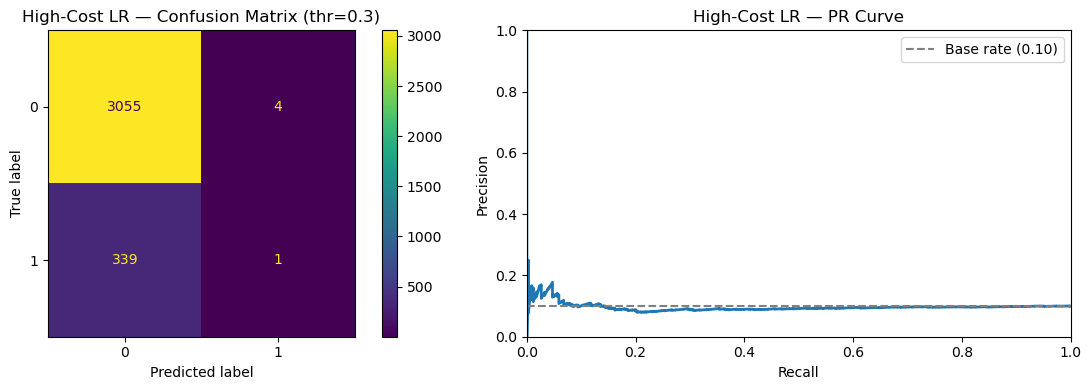

In [16]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(yc_test, (probs_cost >= 0.30).astype(int), labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=axes[0])
axes[0].set_title(f'High-Cost LR — Confusion Matrix (thr={0.30})')

plot_pr_curve(yc_test, probs_cost, 'High-Cost LR — PR Curve', axes[1])
plt.tight_layout()
plt.show()

In [17]:
# # Top coefficients (odds ratios)
# log_reg   = lr_cost.named_steps['clf']
# encoder   = lr_cost.named_steps['prep'].named_transformers_['cat']
# feat_names = np.concatenate([
#     encoder.get_feature_names_out(categorical_fts),
#     np.array(numeric_fts)
# ])

# coef_df = pd.DataFrame({
#     'feature'    : feat_names,
#     'coefficient': log_reg.coef_[0],
#     'odds_ratio' : np.exp(log_reg.coef_[0]),
# }).sort_values('odds_ratio', ascending=False)

# #Top 10 features increasing high-cost probability
# display(coef_df.head(10).style.format({'coefficient': '{:.4f}', 'odds_ratio': '{:.4f}'}))

# #Top 10 features decreasing high-cost probability 
# display(coef_df.tail(10).style.format({'coefficient': '{:.4f}', 'odds_ratio': '{:.4f}'}))

Note: The available features do not carry enough signal to identify high-cost 
patients without direct cost information (ROC-AUC = 0.47). This model underperforms because cost-derived features were removed to prevent leakage (`avg_cost_per_visit` and `total_los_days`)

### For next steps include
- Comorbidity index (Charlson/Elixhauser from existing ICD codes)
- Demographic features (age, payer type, discharge disposition)

---
## 8. Baseline Model 30-Day Readmission

In [18]:
lr_readmit = build_baseline_pipeline(numeric_fts, categorical_fts)
lr_readmit.fit(X_train, yr_train)
probs_readmit = lr_readmit.predict_proba(X_test)[:, 1]

print('=== Readmission Model=========')
print(classification_report(
    yr_test,
    (probs_readmit >= 0.30).astype(int),
    zero_division=0
))

=== Readmission Model=========
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3145
           1       0.61      0.54      0.57       254

    accuracy                           0.94      3399
   macro avg       0.78      0.76      0.77      3399
weighted avg       0.94      0.94      0.94      3399



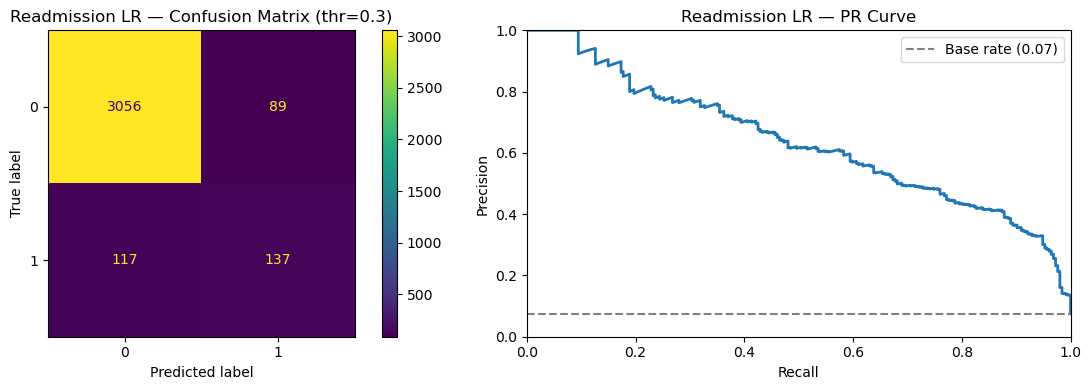

In [19]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_r = confusion_matrix(yr_test, (probs_readmit >= 0.30).astype(int), labels=[0, 1])
ConfusionMatrixDisplay(cm_r, display_labels=[0, 1]).plot(ax=axes[0])
axes[0].set_title(f'Readmission LR — Confusion Matrix (thr={0.30})')

plot_pr_curve(yr_test, probs_readmit, 'Readmission LR — PR Curve', axes[1])
plt.tight_layout()
plt.show()

Note: Clinical complexity variables (`n_unique_dx`, `n_unique_specialties`, 
diagnosis type) relate to readmission risk but not to accumulated cost. 

### For next steps consider
- Reduce FN (117 out of 254 readmissions are missed). 

---
## 9. Results Summary

In [20]:
trivial_probs_readmit = np.full(len(yr_test), yr_train.mean())

results = pd.DataFrame([
    evaluate_model('Trivial — High Cost',   yc_test, trivial_probs_cost,   threshold=0.30),
    evaluate_model('LR — High Cost (p90)',  yc_test, probs_cost,           threshold=0.30),
    evaluate_model('Trivial — Readmission', yr_test, trivial_probs_readmit, threshold=0.30),
    evaluate_model('LR — Readmission',      yr_test, probs_readmit,         threshold=0.30),
])

results.set_index('model').style.format({
    'roc_auc'  : '{:.3f}',
    'pr_auc'   : '{:.3f}',
    'precision': '{:.3f}',
    'recall'   : '{:.3f}',
    'threshold': '{:.2f}',
    'base_rate': '{:.3f}',
}).background_gradient(subset=['roc_auc', 'pr_auc'], cmap='Greens')

,roc_auc,pr_auc,precision,recall,threshold,base_rate
model,,,,,,
Trivial — High Cost,0.500,0.100,0.000,0.000,0.30,0.100
LR — High Cost (p90),0.471,0.098,0.200,0.003,0.30,0.100
Trivial — Readmission,0.500,0.075,0.000,0.000,0.30,0.075
LR — Readmission,0.949,0.638,0.606,0.539,0.30,0.075


---
## 10. Next Steps
```
[ ] Readmission modeled at visit level (predict next admission from current)
[ ] Add demographic features (age group, payer type, discharge disposition)
[ ] Add comorbidity index (Charlson / Elixhauser from ICD codes)
[ ] Gradient Boosting / XGBoost with cross-validated hyperparameter tuning
[ ] SHAP values for feature importance and interpretability? 
```